# Shorting VXX — steady carry, or nickels in front of a steamroller? 📉
### Why a fund that melts away ×100,000 is so tempting to short — and why it can run you over

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_carry%3F: Busted](https://img.shields.io/badge/Free_carry%3F-Busted-8b949e?style=flat-square)

There's a product on the stock exchange whose whole *job* is to lose money. VIX-futures funds like **VXX** (and its longer-lived twin **VIXY**) track stock-market *fear*, and because fear is usually cheap-now / expensive-later, the fund has to keep selling low and buying high every single day. The result is spectacular: it has melted from a split-adjusted **633,840** down to about **22** — a loss of **99.997%**.

So *shorting* it looks like free money: bet against something designed to evaporate. This notebook shows that the carry is **real** — and that it is exactly the kind of real that can wipe you out in an afternoon.

> 📓 **Plain-language layer.** Want the HAC *t*-stat, the placebo test, the skew/kurtosis and the borrow-fee math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** A clean, continuous **VXX** price only exists on yfinance from 2018 (the original note was retired and reissued), which would *miss* the famous Feb-2018 'Volmageddon' blow-up. So we short **VIXY** — the same fear-futures fund with an unbroken history back to 2011 — and call it a VXX-equivalent throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vxx_roll_decay import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real VIX-ETP cache present:", HAVE_REAL,
      "| days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2011-01-04', 'end': '2026-06-22', 'days': 3888, 'years': 15.5, 'daily_mean': 0.171, 'hac_t': 2.51, 'placebo_p': 0.0076, 'frac_contango': 92.3, 'etp_first': 633840, 'etp_last': 21.86, 'etp_ratio': 3.4e-05, 'g_ann': 43.0, 'g_vol': 69.9, 'g_sharpe': 0.62, 'g_dd': -91.8, 'n_ann': 35.1, 'n_sharpe': 0.5, 'n_dd': -93.1, 'skew': -1.65, 'exkurt': 9.4, 'worst': -43.1, 'worst_date': '2024-08-05', 'var1': -14.6, 'cvar1': -20.7, 'worst5': [('2024-08-05', -43.1), ('2020-03-16', -39.1), ('2018-02-05', -34.2), ('2020-06-11', -33.6), ('2020-03-09', -27.4)], 'c_ann': 39.7, 'c_sharpe': 0.67, 'c_dd': -66.7, 'c_skew': -1.3, 'c_t': 3.6, 'borrow': [(0, 38.0, 0.54), (3, 35.1, 0.5), (10, 28.1, 0.4), (30, 8.3, 0.12)], 'syn': [(0.0, -1.99, 0.987, -0.58, -0.4, -100), (0.003, 3.42, 0.0001, 0.99, -0.4, -76)]}


real VIX-ETP cache present: True | days: 3888


## The answer first

| Question | Answer |
|---|---|
| Does shorting the fund actually make money? | **Yes — reliably.** The short earns about **+0.17% a day** on average, **+35%/yr** net of costs. The carry is statistically real (not luck). |
| So it's free money? | **No.** It's the fee for **selling crash insurance.** When fear spikes the fund explodes and the short loses — **-43% in a single day** (Aug 2024), and **-92%** peak-to-trough. |
| How often does the steamroller run? | **Three times in fifteen years** — Volmageddon (2018), COVID (2020), the 2024 yen-carry unwind — each eating a third-to-half of the book in one session. |
| Can you build a fund on it? | **Not at scale.** The carry is real and small; the loss is rare and enormous. Size it to matter and you size it to be wiped out. |

> The carry is real. "Free" is the lie. You are paid a steady nickel to stand in front of a steamroller.

## 1 · The claim

> *"VIX-futures funds are doomed to decay. The futures curve is almost always in **contango** — tomorrow's fear costs more than today's — so the fund must roll from cheap near-month fear into pricey far-month fear, day after day, bleeding value forever. Short it and you harvest that bleed as a steady **carry**."*

It's one of the most popular trades in retail finance, and the decay is no myth: the fund really has lost almost everything. The seductive part is the *steadiness* — most days the fund drifts down and the short ticks up. The dangerous part is what 'most days' is hiding.

## 2 · So what?

Two very different things hide inside "steady carry." (1) *Is there a real edge?* — yes, selling insurance pays a premium on average, that's why insurance exists. (2) *Can you live to collect it?* — that depends entirely on the **tail**. A trade that wins a little almost every day and loses **half its value** on the rare bad day isn't characterised by its average; it's characterised by its worst day. The whole question is whether the steady nickels add up faster than the steamroller takes them away — and whether you survive the gap in between.

## 3 · How would we even know?

We take the real fund (**VIXY**, our VXX-equivalent) over **16 years** (2011-01-04 → 2026-06-22) and run the simplest possible trade: hold a fixed-size **short**, every day.

1. **Measure the carry.** What does the short earn per day on average — and is it real, or could a coin flip have produced it?
2. **Charge the costs.** Shorts pay a **borrow fee**, and rebalancing costs money. Does the carry survive?
3. **Look at the worst days.** Skew, the single ugliest session, the deepest drawdown — the numbers that decide whether you'd still be standing. **If one bad day eats months of carry, it's a steamroller, not a strategy.**

## 4 · The teardown — let's actually look

**First, the decay itself.** Here is the fund's price on a log scale. It doesn't wobble — it *melts*, smoothly, for years. That melt is the carry the short collects.

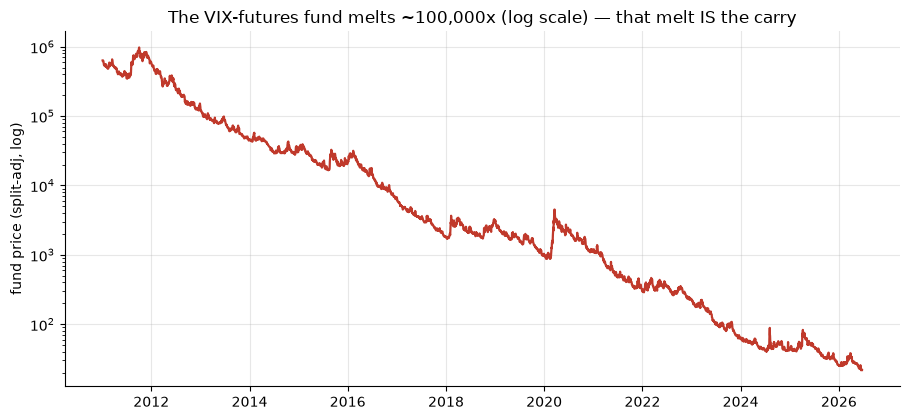

633,840 -> 21.86  (x3.4e-05)


In [2]:
if HAVE_REAL:
    etp = F['etp']
    fig, ax = plt.subplots(figsize=(9.2, 4.3))
    ax.semilogy(etp.index, etp.values, c=RED, lw=1.6)
    ax.set_title('The VIX-futures fund melts ~100,000x (log scale) — that melt IS the carry')
    ax.set_ylabel('fund price (split-adj, log)')
    plt.tight_layout(); plt.show()
    print(f'{etp.iloc[0]:,.0f} -> {etp.iloc[-1]:,.2f}  (x{etp.iloc[-1]/etp.iloc[0]:.1e})')
else:
    print(f"no cache — frozen: {R['etp_first']:,} -> {R['etp_last']:.0f} (x{R['etp_ratio']:.1e})")

From **633,840** to **22**. A near-perfect downhill slide — and the short rides it up. So far, free money. Now turn the page.

**The short's daily returns — almost always a small win, occasionally a catastrophe.** Most bars are tiny green ticks. Watch the few red spikes plunging off the bottom.

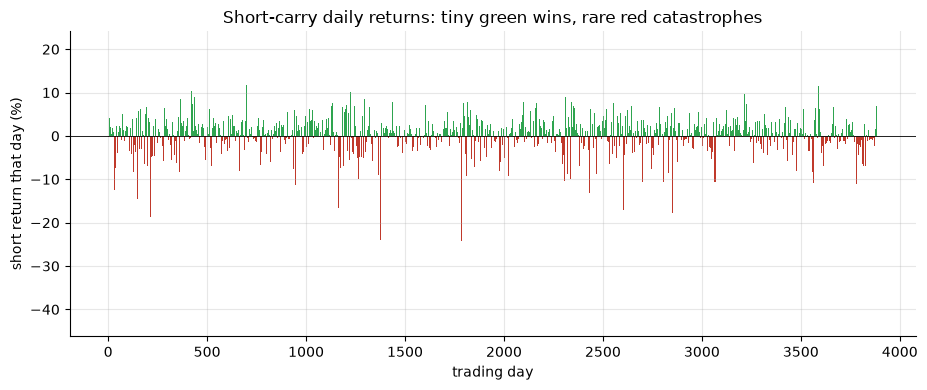

worst single day: -43%  |  median day: +0.62%


In [3]:
if HAVE_REAL:
    rs = st.short_carry(F)
else:
    rng = np.random.default_rng(375)
    rs = rng.normal(R['daily_mean']/100, 0.04, 3800)
    rs[[800, 1900, 3600]] = [-.34, -.39, -.43]   # the three steamroller days
    import pandas as pd; rs = pd.Series(rs)
vals = np.asarray(rs)*100
fig, ax = plt.subplots(figsize=(9.4, 4.0))
ax.bar(range(len(vals)), vals, color=np.where(vals>=0, GREEN, RED), width=1.0)
ax.axhline(0, c='k', lw=.6)
ax.set_title('Short-carry daily returns: tiny green wins, rare red catastrophes')
ax.set_ylabel('short return that day (%)'); ax.set_xlabel('trading day')
plt.tight_layout(); plt.show()
print(f'worst single day: {vals.min():.0f}%  |  median day: {np.median(vals):+.2f}%')

There's the whole story in one picture. The median day is a **+0.6%** nibble; the worst day is **-43%** — more than *three months* of nibbles gone before lunch. The average hides everything that matters.

**The equity curve — and the cliffs.** Compound those daily returns into a constant-size short book. It climbs nicely... and then falls off a cliff, three times.

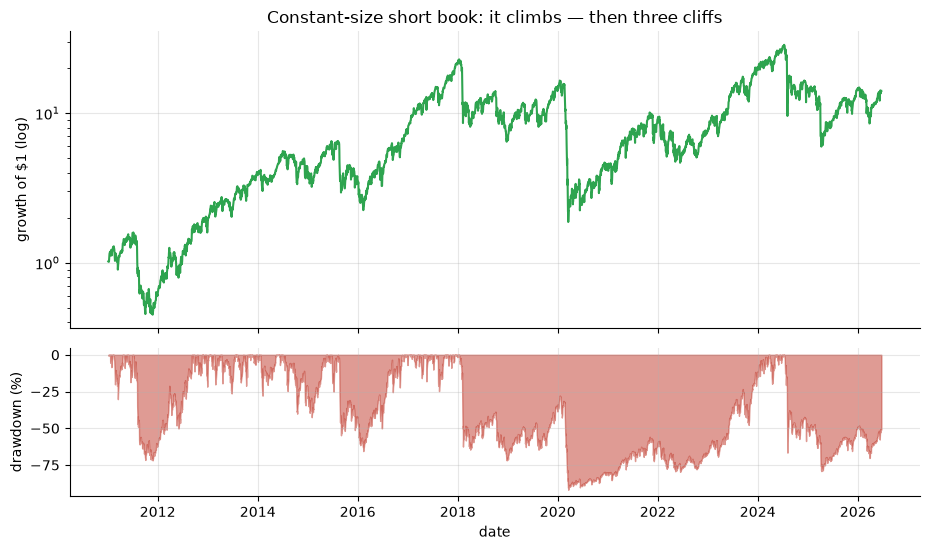

deepest drawdown: -92%


In [4]:
import pandas as pd
if HAVE_REAL:
    rs = st.short_carry(F); idx = F.index[1:]
else:
    rs = pd.Series(rs); idx = pd.RangeIndex(len(rs))
eq = (1+pd.Series(np.asarray(rs), index=idx)).cumprod()
dd = eq/eq.cummax()-1
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.4, 5.6), sharex=True,
                             gridspec_kw={'height_ratios':[2,1]})
a1.plot(eq.index, eq.values, c=GREEN, lw=1.5); a1.set_yscale('log')
a1.set_title('Constant-size short book: it climbs — then three cliffs'); a1.set_ylabel('growth of $1 (log)')
a2.fill_between(dd.index, dd.values*100, 0, color=RED, alpha=.5)
a2.set_ylabel('drawdown (%)'); a2.set_xlabel('date' if HAVE_REAL else 'day')
plt.tight_layout(); plt.show()
print(f'deepest drawdown: {dd.min()*100:.0f}%')

The carry is real — the green line genuinely rises. But the deepest drawdown is **-92%**: at the bottom of a crash the book has given back almost everything. A leveraged version (which is how people actually trade this) would simply be **gone**.

## 5 · The verdict

- **Signal — Real.** The carry isn't an illusion: **+0.17%/day**, real under a proper statistical test (the quants' notebook has the *t* = 2.51). Contango is the usual state and the short genuinely harvests it.
- **Tradability — Fragile.** Net **+35%/yr** looks great until you see the **-43% day** and the **-92% drawdown**. A size that matters is a size that gets wiped out.
- **Free carry? — Busted.** It's not free — it's the premium for selling crash insurance. Steady nickels, occasional steamroller.

## 6 · Could you actually trade it? — meet the steamroller

Forget averages and just stare at the worst days. Here are the five sessions that define the trade — every one a famous volatility blow-up.

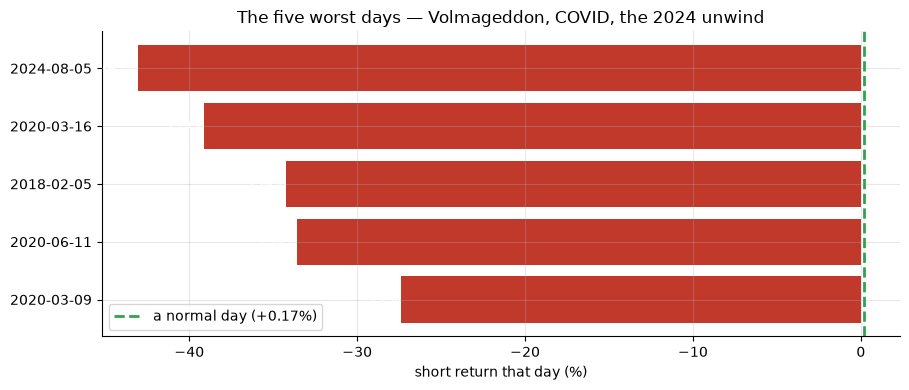

each of these days erases ~6-10 MONTHS of the daily carry


In [5]:
if HAVE_REAL:
    w5 = st.short_carry(F).nsmallest(5)
    labs = [d.date().isoformat() for d in w5.index]; vals = (w5.values*100)
else:
    labs = [d for d,_ in R['worst5']]; vals = [v for _,v in R['worst5']]
fig, ax = plt.subplots(figsize=(9.2, 4.0))
ax.barh(range(len(vals)), vals, color=RED)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(labs); ax.invert_yaxis()
ax.set_xlabel('short return that day (%)')
ax.set_title('The five worst days — Volmageddon, COVID, the 2024 unwind')
for i,v in enumerate(vals): ax.annotate(f'{v:.0f}%',(v,i),ha='right',va='center',color='white')
ax.axvline(R['daily_mean'], c=GREEN, ls='--', lw=2, label=f"a normal day (+{R['daily_mean']:.2f}%)")
ax.legend(loc='lower left'); plt.tight_layout(); plt.show()
print('each of these days erases ~6-10 MONTHS of the daily carry')

The green dashed line is a *normal* day (**+0.17%**). The red bars are **43%, 39%, 34%** single-day losses. Each one undoes most of a year. Costs aren't the problem — a 3% borrow fee barely registers against a 35%/yr carry. **The tail is the problem.** You can't run a fund whose risk is 'and then one day we lose half.'

## 7 · Going further 🚪

- **Try to dodge the steamroller.** Only short when the curve is in contango (a simple filter). It *helps* — the drawdown shrinks from ~92% to ~67% — but a 67% drawdown is still ruinous, and the worst crashes strike *from* contango in hours. The quants' notebook runs it.
- **The borrow trap.** The fund gets **hard to borrow** in exactly the crises when the carry would pay most; at a 30% borrow fee the edge nearly vanishes. The market charges you when you most want in.
- **Size it yourself.** Take the daily returns, apply *your* leverage, and find the size at which the worst day ruins you. That number — not the average — is the trade.

*Think you can keep the carry and skip the steamroller? Build the filter, show the drawdown under a real crash, and survive the next one — then we'll talk.*